# Bibliotecas

In [1]:
import numpy as np
import pandas as pd
import math as m

# Circuito 9 Barras

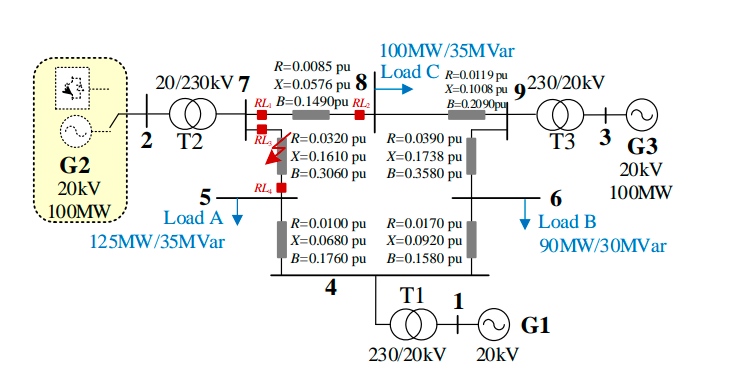

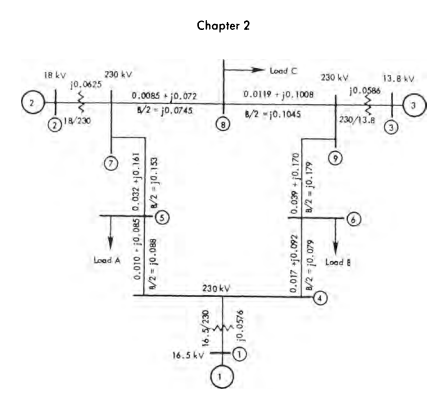

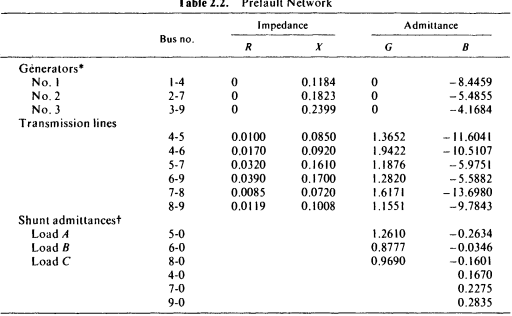

In [ ]:
# Definindo a base
V_base_kV = 20 * 1e3 # kV
S_base_MVA = 100 * 1e6 # MVA


# Convertendo para unidades absolutas
Z_base = (V_base_kV)**2 / (S_base_MVA)  # ohms

In [5]:
Z_base

529.0

In [4]:
entrebarras = [
    (1, 4, 0.0576j), #Trafo barra 1 e 4
    (2, 7, 0.0625j), #Trafo barra 2 e 7
    (3, 9, 0.0586j), #Trafo barra 3 e 9
    (7, 8, 0.0085 + 0.0576j), #Linha barra 7 e 8
    (8, 9, 0.0119 + 0.1008j), #Linha barra 9 e 8
    (7, 5, 0.032 + 0.161j), #Linha barra 7 e 5
    (4, 5, 0.01+ 0.068j), #Linha barra 4 e 5
    (4, 6, 0.017+ 0.092j), #Linha barra 4 e 6
    (9, 6, 0.039+ 0.1738j) #Linha barra 6 e 9
]

impedancias_barra = {
    1: 0.1184j, #Geração Barra 1
    2: 0.1823j, #Geração Barra 2
    3: 0.2399j  #Geração Barra 3
}



In [5]:
f = 60  # Hz
w = 2 * np.pi * f  # rad/s

# Tabela de impedâncias entre barras (ramos)
tabela_ramos = pd.DataFrame([
    {
        "De": de,
        "Para": para,
        "Z_pu": Z,
        "Z_ohm": Z * Z_base,
        "R_ohm": (Z * Z_base).real,          # Resistência
        "X_ohm": (Z * Z_base).imag,          # Reatância
        "L_mH": (Z * Z_base).imag*1000 / w
    }
    for (de, para, Z) in entrebarras
])

# Tabela de impedâncias das barras (geradores)
tabela_geradores = pd.DataFrame([
    {
        "Barra": barra,
        "Z_pu": Z,
        "Z_ohm": Z * Z_base,
        "R_ohm": (Z * Z_base).real,          # Resistência
        "X_ohm": (Z * Z_base).imag,          # Reatância
        "L_mH": (Z * Z_base).imag*1000 / w
    }
    for barra, Z in impedancias_barra.items()
])

print("\n===== IMPEDÂNCIAS ENTRE BARRAS (OHMS) =====\n")
display(tabela_ramos)

print("\n===== IMPEDÂNCIAS DOS GERADORES (OHMS) =====\n")
display(tabela_geradores)

print("\nZ_base =", Z_base, "ohms")


===== IMPEDÂNCIAS ENTRE BARRAS (OHMS) =====



,De,Para,Z_pu,Z_ohm,R_ohm,X_ohm,L_mH
0,1,4,0.0000+0.0576j,0.0000+0.2304j,0.0000,0.2304,0.611155
1,2,7,0.0000+0.0625j,0.0000+0.2500j,0.0000,0.2500,0.663146
2,3,9,0.0000+0.0586j,0.0000+0.2344j,0.0000,0.2344,0.621765
3,7,8,0.0085+0.0576j,0.0340+0.2304j,0.0340,0.2304,0.611155
4,8,9,0.0119+0.1008j,0.0476+0.4032j,0.0476,0.4032,1.069521
5,7,5,0.0320+0.1610j,0.1280+0.6440j,0.1280,0.6440,1.708263
6,4,5,0.0100+0.0680j,0.0400+0.2720j,0.0400,0.2720,0.721502
7,4,6,0.0170+0.0920j,0.0680+0.3680j,0.0680,0.3680,0.976150
8,9,6,0.0390+0.1738j,0.1560+0.6952j,0.1560,0.6952,1.844075



===== IMPEDÂNCIAS DOS GERADORES (OHMS) =====



,Barra,Z_pu,Z_ohm,R_ohm,X_ohm,L_mH
0,1,0.0000+0.1184j,0.0000+0.4736j,0.0,0.4736,1.256263
1,2,0.0000+0.1823j,0.0000+0.7292j,0.0,0.7292,1.934263
2,3,0.0000+0.2399j,0.0000+0.9596j,0.0,0.9596,2.545418



Z_base = 4.0 ohms


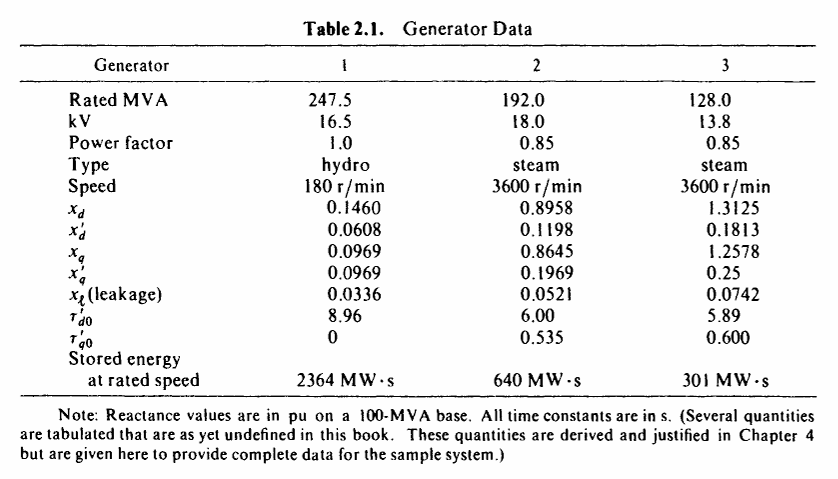

In [27]:
geradores = {
    "G1": {"MVA": 247.5e6, "kV": 16.5, "xd": 0.1460, "xdp": 0.0608, "xq": 0.0969, "xqp": 0.0969, "xl": 0.0336},
    "G2": {"MVA": 192e6,   "kV": 18.0, "xd": 0.8958, "xdp": 0.1198, "xq": 0.8645, "xqp": 0.1969, "xl": 0.0521},
    "G3": {"MVA": 128e6,   "kV": 13.8, "xd": 1.3125, "xdp": 0.1813, "xq": 1.2578, "xqp": 0.25,   "xl": 0.0742},
}

def converter(X_old, kV, MVA):
    Z_global = (kV**2) / S_base_MVA
    Z_gen_base = (kV**2) / MVA
    return (X_old * Z_global) / Z_gen_base

tabela = {}
for g, data in geradores.items():
    linha = {}
    kV = data["kV"]
    MVA = data["MVA"]
    for param in ["xd", "xdp", "xq", "xqp", "xl"]:
        linha[param] = converter(data[param], kV, MVA)
    tabela[g] = linha

df = pd.DataFrame(tabela).T
display(df)

,xd,xdp,xq,xqp,xl
G1,0.361350,0.150480,0.239828,0.239828,0.083160
G2,1.719936,0.230016,1.659840,0.378048,0.100032
G3,1.680000,0.232064,1.609984,0.320000,0.094976


## Funçao

In [7]:
def montar_Ybarra(n_barras, entrebarras, impedancias_barra=None, retornar='Y'):
    """
    Monta a matriz Ybarra (admitância nodal) ou Zbarra (impedância nodal) para um sistema elétrico.

    Parâmetros:
    - n_barras: número total de barras
    - entrebarras: lista de tuplas (de, para, impedância)
    - impedancias_barra: dicionário {barra: Zg} com impedância de geração (opcional)
    - retornar: 'Y' para Ybarra, 'Z' para Zbarra (inversa de Ybarra)

    Retorna:
    - DataFrame da matriz Ybarra ou Zbarra
    """

    Y = np.zeros((n_barras, n_barras), dtype=complex)

    for de, para, z in entrebarras:
        y = 1 / z
        i = de - 1
        j = para - 1
        Y[i, i] += y
        Y[j, j] += y
        Y[i, j] -= y
        Y[j, i] -= y

    if impedancias_barra:
        for barra, zg in impedancias_barra.items():
            y_shunt = 1 / zg
            i = barra - 1
            Y[i, i] += y_shunt

    nomes_barras = [f"Barra {i+1}" for i in range(n_barras)]
    Ybarra_df = pd.DataFrame(Y, index=nomes_barras, columns=nomes_barras)

    if retornar.upper() == 'Y':
        return Ybarra_df
    elif retornar.upper() == 'Z':
        try:
            Z_np = np.linalg.inv(Y)
            Zbarra_df = pd.DataFrame(Z_np, index=nomes_barras, columns=nomes_barras)
            return Zbarra_df
        except np.linalg.LinAlgError:
            raise ValueError("A matriz Ybarra é singular e não pode ser invertida.")
    else:
        raise ValueError("Parâmetro 'retornar' deve ser 'Y' ou 'Z'.")

## Parametros

## **Outputs**

In [8]:
Ybarra = montar_Ybarra(n_barras=9, entrebarras=entrebarras, impedancias_barra=impedancias_barra, retornar="Y")
display(Ybarra.round(4))

,Barra 1,Barra 2,Barra 3,Barra 4,Barra 5,Barra 6,Barra 7,Barra 8,Barra 9
Barra 1,0.0000-25.8071j,0.0000+ 0.0000j,0.0000+ 0.0000j,0.0000+17.3611j,0.0000+ 0.0000j,0.0000+ 0.0000j,0.0000+ 0.0000j,0.0000+ 0.0000j,0.0000+ 0.0000j
Barra 2,0.0000+ 0.0000j,0.0000-21.4855j,0.0000+ 0.0000j,0.0000+ 0.0000j,0.0000+ 0.0000j,0.0000+ 0.0000j,0.0000+16.0000j,0.0000+ 0.0000j,0.0000+ 0.0000j
Barra 3,0.0000+ 0.0000j,0.0000+ 0.0000j,0.0000-21.2332j,0.0000+ 0.0000j,0.0000+ 0.0000j,0.0000+ 0.0000j,0.0000+ 0.0000j,0.0000+ 0.0000j,0.0000+17.0648j
Barra 4,0.0000+17.3611j,0.0000+ 0.0000j,0.0000+ 0.0000j,4.0590-42.2664j,-2.1169+14.3946j,-1.9422+10.5107j,0.0000+ 0.0000j,0.0000+ 0.0000j,0.0000+ 0.0000j
Barra 5,0.0000+ 0.0000j,0.0000+ 0.0000j,0.0000+ 0.0000j,-2.1169+14.3946j,3.3045-20.3697j,0.0000+ 0.0000j,-1.1876+ 5.9751j,0.0000+ 0.0000j,0.0000+ 0.0000j
Barra 6,0.0000+ 0.0000j,0.0000+ 0.0000j,0.0000+ 0.0000j,-1.9422+10.5107j,0.0000+ 0.0000j,3.1714-15.9886j,0.0000+ 0.0000j,0.0000+ 0.0000j,-1.2292+ 5.4779j
Barra 7,0.0000+ 0.0000j,0.0000+16.0000j,0.0000+ 0.0000j,0.0000+ 0.0000j,-1.1876+ 5.9751j,0.0000+ 0.0000j,3.6950-38.9662j,-2.5074+16.9911j,0.0000+ 0.0000j
Barra 8,0.0000+ 0.0000j,0.0000+ 0.0000j,0.0000+ 0.0000j,0.0000+ 0.0000j,0.0000+ 0.0000j,0.0000+ 0.0000j,-2.5074+16.9911j,3.6625-26.7754j,-1.1551+ 9.7843j
Barra 9,0.0000+ 0.0000j,0.0000+ 0.0000j,0.0000+17.0648j,0.0000+ 0.0000j,0.0000+ 0.0000j,-1.2292+ 5.4779j,0.0000+ 0.0000j,-1.1551+ 9.7843j,2.3843-32.3270j


In [9]:
Z_base

4.0

In [10]:
Zbarra = montar_Ybarra(n_barras=9, entrebarras=entrebarras, impedancias_barra=impedancias_barra, retornar="Z")
Zbarra_ohm = Zbarra * Z_base
display(Zbarra_ohm.round(4))

,Barra 1,Barra 2,Barra 3,Barra 4,Barra 5,Barra 6,Barra 7,Barra 8,Barra 9
Barra 1,0.0072+0.3447j,-0.0059+0.1087j,-0.0068+0.1183j,0.0107+0.2819j,0.0066+0.2416j,0.0052+0.2354j,-0.0079+0.1459j,-0.0081+0.1464j,-0.0085+0.1471j
Barra 2,-0.0059+0.1087j,0.0100+0.4374j,-0.0014+0.1639j,-0.0087+0.1615j,-0.0040+0.2136j,-0.0066+0.1762j,0.0135+0.3373j,0.0071+0.2888j,-0.0017+0.2039j
Barra 3,-0.0068+0.1183j,-0.0014+0.1639j,0.0156+0.5044j,-0.0101+0.1758j,-0.0081+0.1889j,-0.0018+0.2509j,-0.0018+0.2200j,0.0071+0.2830j,0.0194+0.3932j
Barra 4,0.0107+0.2819j,-0.0087+0.1615j,-0.0101+0.1758j,0.0158+0.4191j,0.0098+0.3592j,0.0078+0.3499j,-0.0117+0.2169j,-0.0120+0.2176j,-0.0126+0.2187j
Barra 5,0.0066+0.2416j,-0.0040+0.2136j,-0.0081+0.1889j,0.0098+0.3592j,0.0371+0.5290j,0.0040+0.3163j,-0.0054+0.2869j,-0.0074+0.2680j,-0.0101+0.2351j
Barra 6,0.0052+0.2354j,-0.0066+0.1762j,-0.0018+0.2509j,0.0078+0.3499j,0.0040+0.3163j,0.0524+0.5775j,-0.0089+0.2366j,-0.0060+0.2641j,-0.0023+0.3122j
Barra 7,-0.0079+0.1459j,0.0135+0.3373j,-0.0018+0.2200j,-0.0117+0.2169j,-0.0054+0.2869j,-0.0089+0.2366j,0.0181+0.4530j,0.0095+0.3878j,-0.0023+0.2738j
Barra 8,-0.0081+0.1464j,0.0071+0.2888j,0.0071+0.2830j,-0.0120+0.2176j,-0.0074+0.2680j,-0.0060+0.2641j,0.0095+0.3878j,0.0291+0.5214j,0.0088+0.3521j
Barra 9,-0.0085+0.1471j,-0.0017+0.2039j,0.0194+0.3932j,-0.0126+0.2187j,-0.0101+0.2351j,-0.0023+0.3122j,-0.0023+0.2738j,0.0088+0.3521j,0.0242+0.4892j


## Impedancia de Thevenin

In [11]:
# Pegando o valor Z22 (Barra 2 x Barra 2)
Z22 = Zbarra_ohm.loc["Barra 2", "Barra 2"]

# Separando resistência (R) e reatância indutiva (X)
Rth = Z22.real
X = Z22.imag
Lth = X / (2 * np.pi * 60)
print(f"Z22 = {Z22:.4f} ohms")
print(f"Resistência (R) = {Rth} ohms")
print(f"Indutância (L) = {Lth} H")  # usando frequência de 60 Hz

Z22 = 0.0100+0.4374j ohms
Resistência (R) = 0.010038656529756919 ohms
Indutância (L) = 0.0011601815110534163 H


In [12]:
# Separando resistência (R) e reatância indutiva (X)
R = (impedancias_barra[2]).real
X = (impedancias_barra[2]).imag

print(f"ZG2 = {impedancias_barra[2]:.4f} ohms")
print(f"Resistência (R) = {R} ohms")
print(f"Indutância (L) = {X / (2 * np.pi * 60)} H")  # usando frequência de 60 Hz

ZG2 = 0.0000+0.1823j ohms
Resistência (R) = 0.0 ohms
Indutância (L) = 0.00048356576876087536 H


In [13]:
# Separando resistência (R) e reatância indutiva (X)
Xfault = Z_base*0.5

print(f"Reatancia de falta (L) = {Xfault} ohms")
print(f"Indutância de falta (L) = {Xfault / (2 * np.pi * 60)} H")  # usando frequência de 60 Hz

Reatancia de falta (L) = 2.0 ohms
Indutância de falta (L) = 0.005305164769729845 H


# Cálculo do Filtro LCL

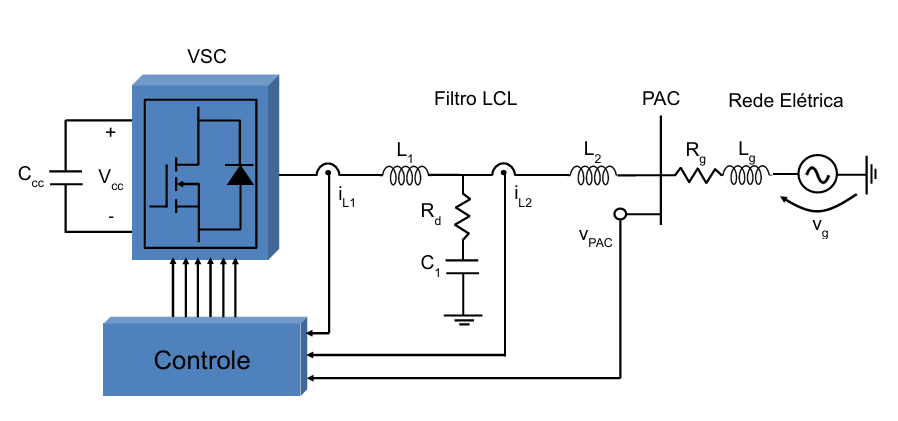

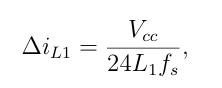

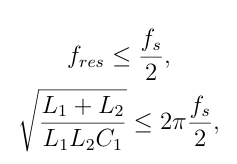

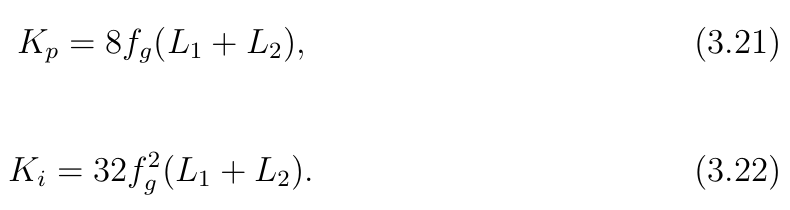

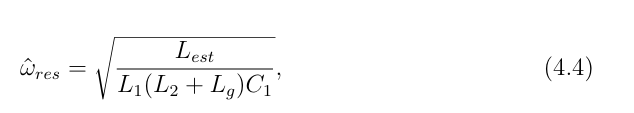

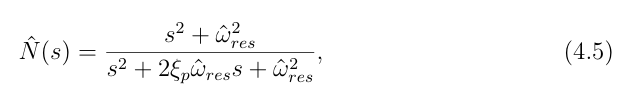

In [14]:
# ===== Dados do sistema =====
V_rms = V_base_kV
S_nom = S_base_MVA
Lg = 0               # Indutância da rede (se houver, colocar valor)
f = 60               # Frequência da rede em Hz
fs = 5e3             # Frequência de comutação do inversor em Hz (chute inicial)
k = 0.0095              # Razão L2/L1

# ===== Cálculo de correntes =====

I_nom = S_nom / (V_rms * m.sqrt(3))
I_pico = (S_nom * m.sqrt(2/3)) / V_rms

# ===== Tensão do barramento DC =====
#Vcc = V_rms * m.sqrt(2/3) * 2*4.5
Vcc = ((V_rms * 500)/220)*2
# ===== Ripple permitido =====
Iripple = I_pico * 0.0061  # 0,5% do pico nominal

# ===== Indutâncias L1 e L2 =====
L1 = Vcc / (Iripple * 24 * fs)
L2 = k * L1
Lest = L1 + L2 + Lg

# ===== Capacitor do filtro =====
C1x = (L1 + L2) / (L1 * L2 * (m.pi * fs)**2)
C1 = C1x * 3


# ===== Resistores de amortecimento =====
omega_g = 2 * m.pi * f
Rd1 = 0.05 * omega_g * L1
Rd2 = 0.05 * omega_g * L2
Rd3 = 0.05 / (omega_g * C1)

# ===== Ganhos do controlador =====
Kp = 8 * 60 * (L1 + L2 + Lest)
Ki = 32 * 60**2 * (L1 + L2 + Lest)

wres = m.sqrt((L1+L2+Lg)/(L1*(L2+Lg)*C1))

In [15]:
print("Vcc =", Vcc)
print("L1 =", L1)
print("L2 =", L2)

print("C1 =", C1)
print("Rd1 =", Rd1)
print("Rd2 =", Rd2)
print("Rd3 =", Rd3)

print("Kp =", Kp, "/4")
print("Ki =", Ki, "/4")
print("qsi =", 0.707)
print("wres =",wres)

print("Rth =", Rth)
print("Lth =", Lth)

Vcc = 90909.09090909091
L1 = 0.03042088602562317
L2 = 0.0002889984172434201
C1 = 4.247098756978487e-05
Rd1 = 0.5734201923227409
Rd2 = 0.0054474918270660385
Rd3 = 3.1228169353331086
Kp = 29.481489065151926 /4
Ki = 7075.557375636462 /4
qsi = 0.707
wres = 9068.99682117109
Rth = 0.010038656529756919
Lth = 0.0011601815110534163


In [16]:
1-(1/60)

0.9833333333333333

In [17]:
#Iripple = I_pico * 0.004
#Iripple

In [18]:
print(2*m.pi*fs/2)
print(2*m.pi*fs)

15707.963267948966
31415.926535897932


In [19]:
print(m.sqrt((L1+L2)/(L1*L2*C1x)))
print(m.sqrt((L1+L2)/(L1*L2*C1)))

15707.963267948966
9068.99682117109


In [20]:
# ===== Resultados =====
print("Vcc [kV]:", Vcc)
print("L1 [H]:", L1)
print("L2 [H]:", L2)
print("Lest [H]:", Lest)
print("C1 [F]:", C1)
print("Rd1 (L1) [Ohm]:", Rd1)
print("Rd2 (L2) [Ohm]:", Rd2)
print("Rd3 (C1) [Ohm]:", Rd3)
print("Rdest (Lest) [Ohm]:", Rd1+Rd2)
print("Kp:", Kp)
print("Ki:", Ki)
print("Ti:", Kp/Ki)
print("w:",wres)

Vcc [kV]: 90909.09090909091
L1 [H]: 0.03042088602562317
L2 [H]: 0.0002889984172434201
Lest [H]: 0.03070988444286659
C1 [F]: 4.247098756978487e-05
Rd1 (L1) [Ohm]: 0.5734201923227409
Rd2 (L2) [Ohm]: 0.0054474918270660385
Rd3 (C1) [Ohm]: 3.1228169353331086
Rdest (Lest) [Ohm]: 0.5788676841498069
Kp: 29.481489065151926
Ki: 7075.557375636462
Ti: 0.004166666666666667
w: 9068.99682117109


In [21]:
omega_g = 2*m.pi*f

Rd1 = 0.05 * omega_g * L1
Rd2 = 0.05 * omega_g * L2

In [22]:
print("Rd1 (L1) [Ohm]:", Rd1)
print("Rd2 (L2) [Ohm]:", Rd2)

Rd1 (L1) [Ohm]: 0.5734201923227409
Rd2 (L2) [Ohm]: 0.0054474918270660385


In [23]:
Kp = 8*60*(L1+L2+Lest)
Ki = 32*(60**2)*(L1+L2+Lest)

In [24]:
print("Kp=",Kp)
print("Ki=",Ki)

Kp= 29.481489065151926
Ki= 7075.557375636462


In [25]:
print(wres)
print(Lest)

9068.99682117109
0.03070988444286659
